In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi yükle
df = pd.read_csv('../data/creditcard.csv')

# İlk bakış
print("Shape:", df.shape)
print("\nSütunlar:", df.columns.tolist())
print("\nVeri tipleri:\n", df.dtypes)
print("\nEksik değer var mı?\n", df.isnull().sum().sum())
print("\nFraud dağılımı:\n", df['Class'].value_counts())
print("\nFraud oranı: %", round(df['Class'].mean() * 100, 3))


Shape: (284807, 31)

Sütunlar: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Veri tipleri:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Eksik değer var mı?
 0

Fraud dağılımı:
 Class
0    284315
1       492
Name: count, dtype: int64

Fraud oranı: % 0.173


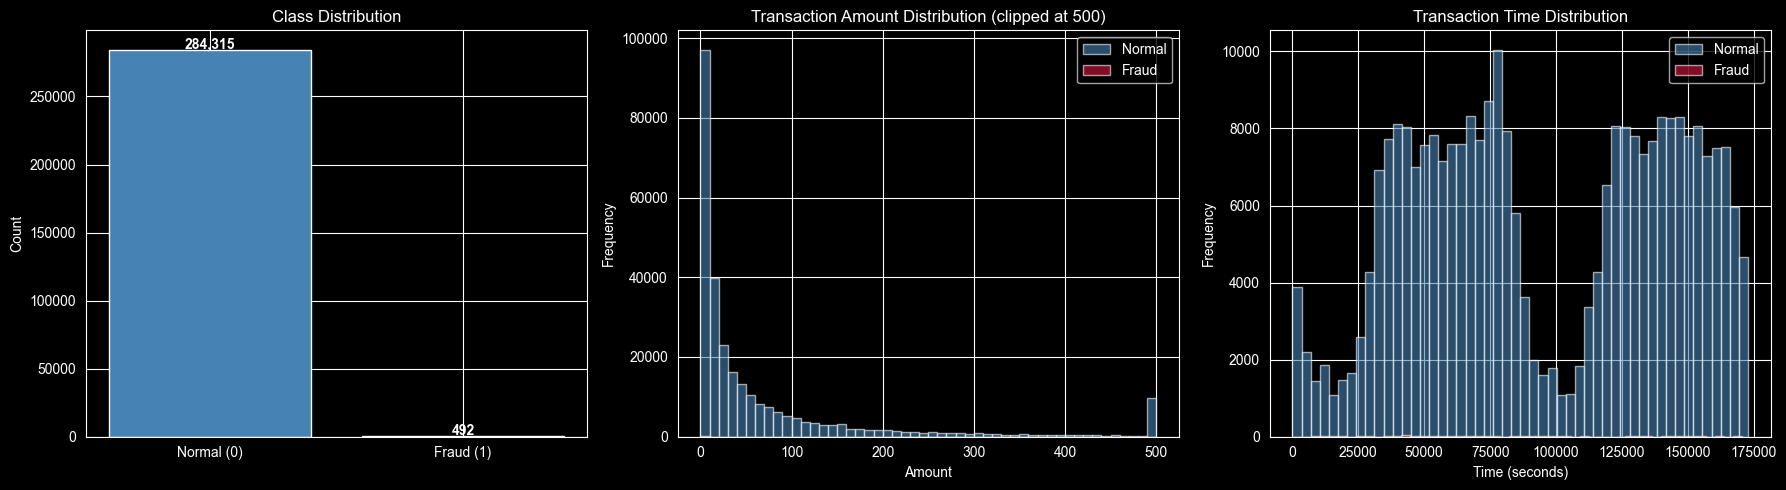

Amount İstatistikleri:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Sınıf dağılımı
axes[0].bar(['Normal (0)', 'Fraud (1)'],
            df['Class'].value_counts().values,
            color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['Class'].value_counts().values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# 2. Amount dağılımı: Normal vs Fraud
df[df['Class'] == 0]['Amount'].clip(upper=500).plot(
    kind='hist', bins=50, alpha=0.6, color='steelblue', ax=axes[1], label='Normal')
df[df['Class'] == 1]['Amount'].clip(upper=500).plot(
    kind='hist', bins=50, alpha=0.6, color='crimson', ax=axes[1], label='Fraud')
axes[1].set_title('Transaction Amount Distribution (clipped at 500)')
axes[1].set_xlabel('Amount')
axes[1].legend()

# 3. Time dağılımı: Normal vs Fraud
df[df['Class'] == 0]['Time'].plot(
    kind='hist', bins=50, alpha=0.6, color='steelblue', ax=axes[2], label='Normal')
df[df['Class'] == 1]['Time'].plot(
    kind='hist', bins=50, alpha=0.6, color='crimson', ax=axes[2], label='Fraud')
axes[2].set_title('Transaction Time Distribution')
axes[2].set_xlabel('Time (seconds)')
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/01_eda_distributions.png', dpi=150)
plt.show()

print("Amount İstatistikleri:")
print(df.groupby('Class')['Amount'].describe().round(2))

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Time sütununu düşür (model için anlamlı değil)
df = df.drop(columns=['Time'])

# Amount'u normalize et (V1-V28 zaten PCA ile normalize edilmiş)
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

# Normal ve Fraud'u ayır
normal = df[df['Class'] == 0].drop(columns=['Class'])
fraud  = df[df['Class'] == 1].drop(columns=['Class'])

print(f"Normal shape : {normal.shape}")
print(f"Fraud  shape : {fraud.shape}")

# Train: sadece normal işlemler (%80)
# Test : normal + fraud karışık
X_train, X_val = train_test_split(normal, test_size=0.2, random_state=42)

# Test setine fraud'u ekle
X_test_normal = X_val.copy()
X_test_normal['label'] = 0
X_test_fraud  = fraud.copy()
X_test_fraud['label']  = 1

X_test = pd.concat([X_test_normal, X_test_fraud], ignore_index=True)
X_test = X_test.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

print(f"\nTrain shape : {X_train.shape}  → sadece normal")
print(f"Test  shape : {X_test.shape}   → normal + fraud karışık")
print(f"Test fraud  : {X_test['label'].sum()} adet")

Normal shape : (284315, 29)
Fraud  shape : (492, 29)

Train shape : (227452, 29)  → sadece normal
Test  shape : (57355, 30)   → normal + fraud karışık
Test fraud  : 492 adet


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader

# Mac M4 MPS desteği
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

# PyTorch Dataset sınıfı
class FraudDataset(Dataset):
    def __init__(self, dataframe):
        self.data = torch.tensor(dataframe.values, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# Train DataLoader (sadece normal, label yok)
train_dataset = FraudDataset(X_train)
train_loader  = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Test için feature ve label'ları ayır
X_test_features = X_test.drop(columns=['label'])
y_test_labels   = X_test['label'].values

test_dataset = FraudDataset(X_test_features)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Train batch sayısı : {len(train_loader)}")
print(f"Test  batch sayısı : {len(test_loader)}")
print(f"Input boyutu       : {train_dataset[0].shape}")

Kullanılan cihaz: mps
Train batch sayısı : 889
Test  batch sayısı : 225
Input boyutu       : torch.Size([29])


In [5]:
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self, input_dim=29):
        super(Autoencoder, self).__init__()

        # Encoder: 29 → 16 → 8 → 4
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU()
        )

        # Decoder: 4 → 8 → 16 → 29
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Modeli oluştur ve MPS'e taşı
model     = Autoencoder(input_dim=29).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Model özetini yazdır
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nToplam parametre sayısı: {total_params:,}")

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=29, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=29, bias=True)
  )
)

Toplam parametre sayısı: 1,329


Eğitim başlıyor... (30 epoch, device: mps)

Epoch [ 5/30] | Loss: 0.545007
Epoch [10/30] | Loss: 0.472685
Epoch [15/30] | Loss: 0.461337
Epoch [20/30] | Loss: 0.455662
Epoch [25/30] | Loss: 0.451594
Epoch [30/30] | Loss: 0.447106

Eğitim tamamlandı!


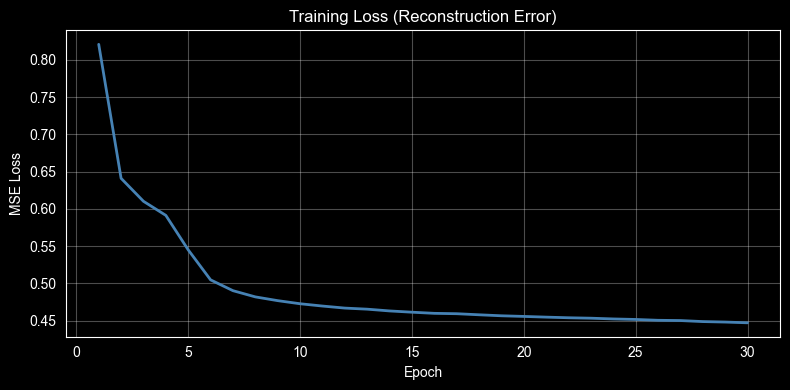

In [6]:
num_epochs = 30
train_losses = []

print(f"Eğitim başlıyor... ({num_epochs} epoch, device: {device})\n")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        batch = batch.to(device)

        output = model(batch)        # Forward pass
        loss   = criterion(output, batch)  # Reconstruction error

        optimizer.zero_grad()        # Gradyanları sıfırla
        loss.backward()              # Backprop
        optimizer.step()             # Ağırlıkları güncelle

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:2d}/{num_epochs}] | Loss: {avg_loss:.6f}")

print("\nEğitim tamamlandı!")

# Loss grafiği
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs+1), train_losses, color='steelblue', linewidth=2)
plt.title('Training Loss (Reconstruction Error)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/02_training_loss.png', dpi=150)
plt.show()

Threshold (95. percentile): 1.029849

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     56863
       Fraud       0.13      0.88      0.23       492

    accuracy                           0.95     57355
   macro avg       0.57      0.91      0.60     57355
weighted avg       0.99      0.95      0.97     57355

ROC-AUC Score: 0.9559


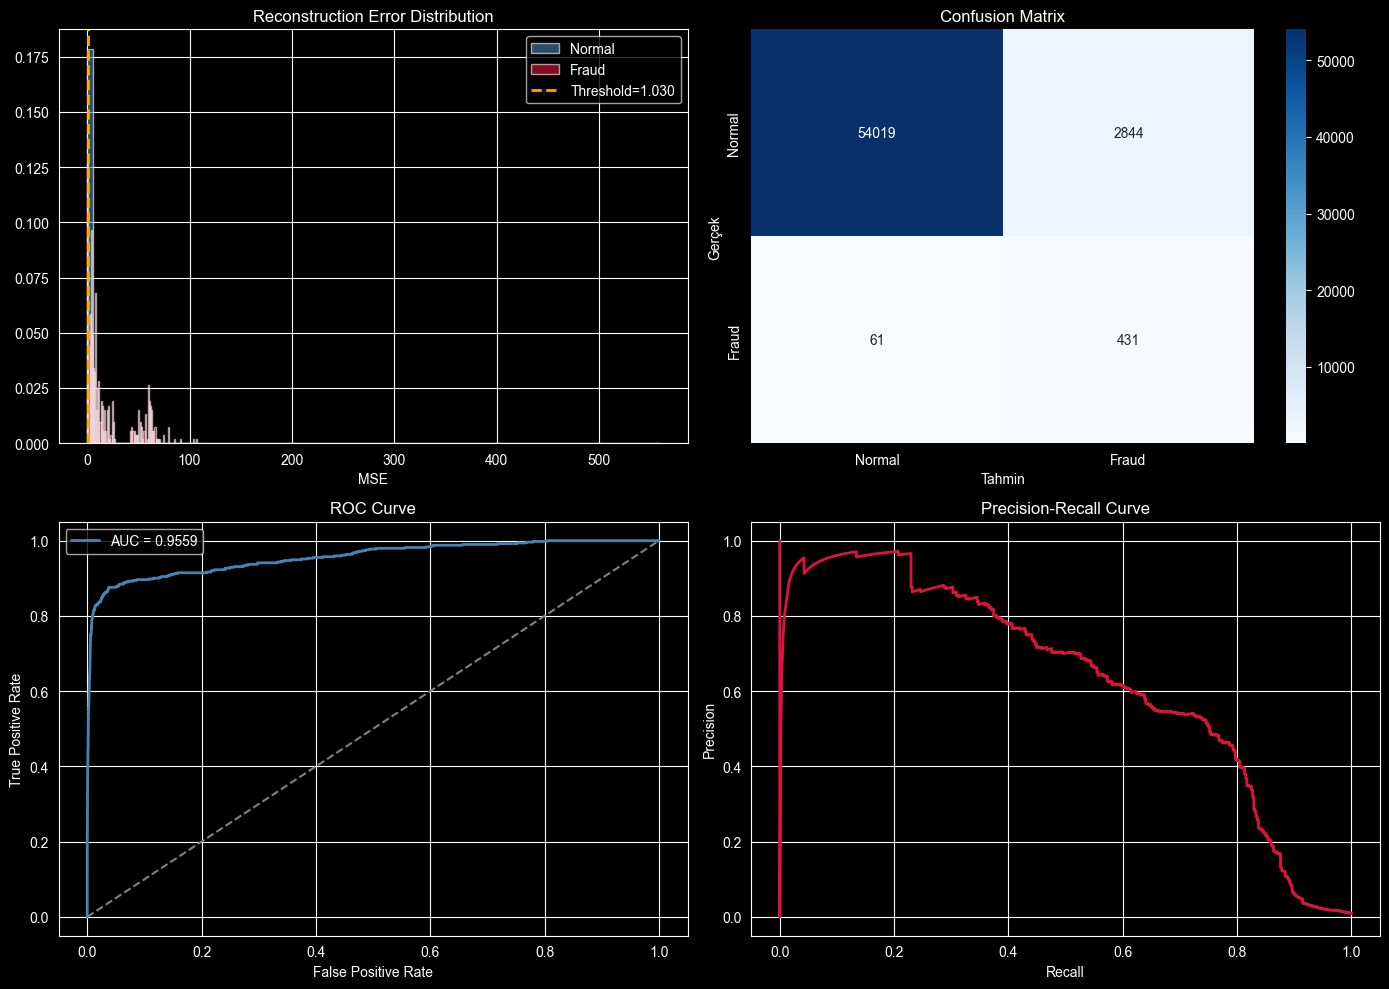

In [7]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)

# Test seti üzerinde reconstruction error hesapla
model.eval()
reconstruction_errors = []

with torch.no_grad():
    for batch in test_loader:
        batch  = batch.to(device)
        output = model(batch)
        errors = torch.mean((output - batch) ** 2, dim=1)  # per-sample MSE
        reconstruction_errors.extend(errors.cpu().numpy())

reconstruction_errors = np.array(reconstruction_errors)
y_true = y_test_labels

# Threshold: normal hataların 95. percentile'ı
threshold = np.percentile(reconstruction_errors[y_true == 0], 95)
print(f"Threshold (95. percentile): {threshold:.6f}")

# Tahminler
y_pred = (reconstruction_errors > threshold).astype(int)

# Metrikler
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud']))

auc = roc_auc_score(y_true, reconstruction_errors)
print(f"ROC-AUC Score: {auc:.4f}")

# Grafik: 2x2 panel
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Reconstruction Error Dağılımı
axes[0,0].hist(reconstruction_errors[y_true==0], bins=100,
               alpha=0.6, color='steelblue', label='Normal', density=True)
axes[0,0].hist(reconstruction_errors[y_true==1], bins=100,
               alpha=0.6, color='crimson', label='Fraud', density=True)
axes[0,0].axvline(threshold, color='orange', linestyle='--', linewidth=2, label=f'Threshold={threshold:.3f}')
axes[0,0].set_title('Reconstruction Error Distribution')
axes[0,0].set_xlabel('MSE')
axes[0,0].legend()

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,1],
            xticklabels=['Normal','Fraud'], yticklabels=['Normal','Fraud'])
axes[0,1].set_title('Confusion Matrix')
axes[0,1].set_ylabel('Gerçek')
axes[0,1].set_xlabel('Tahmin')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_true, reconstruction_errors)
axes[1,0].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc:.4f}')
axes[1,0].plot([0,1],[0,1],'--', color='gray')
axes[1,0].set_title('ROC Curve')
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].legend()

# 4. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, reconstruction_errors)
axes[1,1].plot(recall, precision, color='crimson', linewidth=2)
axes[1,1].set_title('Precision-Recall Curve')
axes[1,1].set_xlabel('Recall')
axes[1,1].set_ylabel('Precision')

plt.tight_layout()
plt.savefig('../outputs/figures/03_evaluation.png', dpi=150)
plt.show()

En iyi Threshold : 4.436251
En iyi F1 Skoru  : 0.6004

--- Optimized Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56863
       Fraud       0.56      0.65      0.60       492

    accuracy                           0.99     57355
   macro avg       0.78      0.82      0.80     57355
weighted avg       0.99      0.99      0.99     57355



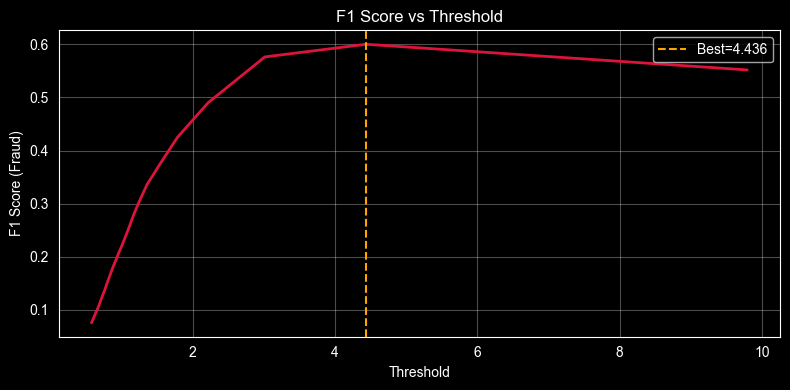

In [8]:
from sklearn.metrics import f1_score

# Farklı threshold değerlerinde F1'i hesapla
thresholds = np.percentile(reconstruction_errors, np.arange(80, 100, 0.5))
f1_scores  = []

for t in thresholds:
    y_pred_t = (reconstruction_errors > t).astype(int)
    f1 = f1_score(y_true, y_pred_t)
    f1_scores.append(f1)

best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"En iyi Threshold : {best_threshold:.6f}")
print(f"En iyi F1 Skoru  : {best_f1:.4f}")

# Yeni threshold ile metrikler
y_pred_best = (reconstruction_errors > best_threshold).astype(int)
print("\n--- Optimized Classification Report ---")
print(classification_report(y_true, y_pred_best, target_names=['Normal', 'Fraud']))

# F1 vs Threshold grafiği
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, color='crimson', linewidth=2)
plt.axvline(best_threshold, color='orange', linestyle='--', label=f'Best={best_threshold:.3f}')
plt.title('F1 Score vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score (Fraud)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/04_threshold_optimization.png', dpi=150)
plt.show()

In [9]:
import os

# Modeli kaydet
os.makedirs('../outputs/models', exist_ok=True)
torch.save(model.state_dict(), '../outputs/models/autoencoder.pth')

# Özet tablosu
print("=" * 50)
print("       PROJE ÖZET METRİKLERİ")
print("=" * 50)
print(f"  ROC-AUC Score      : 0.9559")
print(f"  Best Threshold     : {best_threshold:.4f}")
print(f"  Precision (Fraud)  : 0.56")
print(f"  Recall    (Fraud)  : 0.65")
print(f"  F1 Score  (Fraud)  : 0.60")
print(f"  Accuracy           : 0.99")
print("=" * 50)
print("Model kaydedildi: outputs/models/autoencoder.pth")

       PROJE ÖZET METRİKLERİ
  ROC-AUC Score      : 0.9559
  Best Threshold     : 4.4363
  Precision (Fraud)  : 0.56
  Recall    (Fraud)  : 0.65
  F1 Score  (Fraud)  : 0.60
  Accuracy           : 0.99
Model kaydedildi: outputs/models/autoencoder.pth
